In [501]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import pandas_ta as ta
import math
from tqdm import tqdm
import gc
import time
import json
# import pandas_ta
# import talib
import pickle
# from position_tools import calculate_trades, calculate_positions, count_since_last_signal

# from pklibs import *

import logging

# Configure logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


from pklib.strategy import *
from pklib.utilities import *
from pklib.pkindicators import calculate_zigzag
from pklib.indicators import *


import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from stable_baselines3 import PPO, A2C, DDPG, DQN, SAC
from stable_baselines3 import TD3
from stable_baselines3.common.noise import NormalActionNoise
import pandas as pd
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.logger import configure

In [ ]:
ldf_ichimoku

In [ ]:
def load_ichi_df(df, params):
    df_ichimoku = ichimoku_cloud_indicator(df, **params).join(df[['high','low','close','open']]).dropna()
    ldf_ichimoku = df_ichimoku.apply(np.log
    ).assign(tenkan_minus_kijun=lambda ldf: ldf.tenkan - ldf.kijun
    ).assign(close_minus_upper=lambda ldf: ldf.close - ldf.kumo_upper
    ).assign(close_minus_high=lambda ldf: ldf.close - ldf.kumo_upper
    ).assign(close_minus_low=lambda ldf: ldf.close - ldf.kumo_upper
    ).assign(close_minus_open=lambda ldf: ldf.close - ldf.kumo_upper
    ).assign(close_minus_kijun=lambda ldf: ldf.close - ldf.kijun
    ).assign(close_minus_tenkan=lambda ldf: ldf.close - ldf.tenkan
    ).assign(upper_minus_lower=lambda ldf: ldf.kumo_upper - ldf.kumo_lower
    ).assign(spanA_minus_spanB=lambda ldf: ldf.lead_span_A - ldf.lead_span_B
    )
    logprice = ldf_ichimoku.close.copy()
    return logprice, ldf_ichimoku

In [ ]:
def make_ichimoku_trading_env(exchange, asset, quote, timeframe, lookback_window_size):
    df = load_candles(exchange,asset, quote, timeframe)[:'2022']#.iloc[-35000:-5000]
    params = {'conversion_periods':30, 'base_periods':160, 'lagging_span2_periods':220, 'displacement':90}
    logprice, ldf_ichimoku = load_ichi_df(df, params)
    # features = ['tenkan_minus_kijun', 'close_minus_upper','close_minus_kijun', 'close_minus_tenkan', 'upper_minus_lower','close','open','low','high','lead_span_A','lead_span_B']
    features = ['tenkan_minus_kijun', 'close_minus_upper','close_minus_kijun', 'close_minus_tenkan', 'upper_minus_lower','close']
    return TradingEnv(ldf_ichimoku[features], logprice, lookback_window_size=lookback_window_size)

In [ ]:


num_cpu = os.cpu_count()

exchange, asset, quote, timeframe =  'binance', 'BTC', 'USDT', '4h'
df = load_candles(exchange,asset, quote, timeframe)[:'2022']#.iloc[-35000:-5000]
params = {'conversion_periods':30, 'base_periods':160, 'lagging_span2_periods':220, 'displacement':90}
logprice, ldf_ichimoku = load_ichi_df(df, params)
# features = ['tenkan_minus_kijun', 'close_minus_upper','close_minus_kijun', 'close_minus_tenkan', 'upper_minus_lower','close','open','low','high','lead_span_A','lead_span_B']
features = ['tenkan_minus_kijun', 'close_minus_upper','close_minus_kijun', 'close_minus_tenkan', 'upper_minus_lower','close']
lookback_window_size=2
# Wrap the environment
env = DummyVecEnv([lambda: TradingEnv(ldf_ichimoku[features], logprice, lookback_window_size=lookback_window_size)])
# Use VecNormalize to normalize both observations and rewards
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10., clip_reward=10.)

net_arch = [6,10,3]
policy_kwargs = dict(policy_kwargs=dict(net_arch=net_arch))
# model = DQN("MlpPolicy", env, verbose=2, learning_rate=0.0001, policy_kwargs=policy_kwargs )
model = DQN(
    "MlpPolicy", 
    env,
    policy_kwargs=dict(net_arch=net_arch),
    learning_rate=0.0001,  # Initial learning rate
    exploration_initial_eps=0.9,  
    exploration_final_eps=0.03,  
    gamma=0.995,
    verbose=1,
)


# Set up tensorboard logging
new_logger = configure('tensorboard_logs/', ["stdout", "tensorboard"])
model.set_logger(new_logger)

custom_logger = CustomLoggingCallback()


# Initialize adaptive learning rate callback
adaptive_lr_callback = AdaptiveLearningRate(initial_lr=0.0005, reward_threshold=1,verbose=1)
reward_scaler_callback = VarianceRewardScaler(window_size=100, epsilon=1e-6, verbose=0)
lr_scheduler = LearningRateScheduler(initial_lr=0.0006, decay_rate=0.99)

# Train the model with the adaptive learning rate callback
# model.learn(total_timesteps=100000, callback=[reward_scaler_callback, custom_logger])

pnl_logging_callback = PnLLoggingCallback()
custom_callback = CustomLoggingCallback()
# ,custom_callback,reward_scaler_callback
model.learn(total_timesteps=50000, log_interval=1, callback=[pnl_logging_callback,adaptive_lr_callback])

# Save the trained model
model.save("dqn_custom_policy")

env.save("vec_normalize.pkl")
# tensorboard --logdir tensorboard_logs/

In [ ]:
# Load the previously saved model
lookback_window_size=2
env = VecNormalize.load("vec_normalize.pkl", DummyVecEnv([lambda: TradingEnv(ldf_ichimoku[features], logprice, lookback_window_size=lookback_window_size)]))

# Load the trained model
model = DQN.load("dqn_custom_policy", env=env)


adaptive_lr_callback = AdaptiveLearningRate(initial_lr=0.0001, reward_threshold=100)
reward_scaler_callback = VarianceRewardScaler(window_size=100, epsilon=1e-6, verbose=0)

# Train the model with the adaptive learning rate callback
# model.learn(total_timesteps=100000, callback=[reward_scaler_callback, custom_logger])

pnl_logging_callback = PnLLoggingCallback()
custom_callback = CustomLoggingCallback()
# ,custom_callback,reward_scaler_callback
model.learn(total_timesteps=100000, callback=[pnl_logging_callback,reward_scaler_callback])


# Optionally, save again after additional training
model.save("dqn_custom_policy")

## SARSA + >Decision Tree Q-Approximator

In [396]:
df_comp_features.columns

Index(['tenkan_gt_kijun', 'tenkan_gt_close', 'kijun_gt_close',
       'kumo_upper_gt_close', 'lead_span_A_gt_lead_span_B',
       'lead_span_A_gt_close', 'lead_span_B_gt_close'],
      dtype='object')

Training set size: 789
Test set size: 198


In [484]:
df_comp_features

,tenkan_gt_kijun,tenkan_gt_close,kijun_gt_close,kumo_upper_gt_close,lead_span_A_gt_lead_span_B,lead_span_A_gt_close,lead_span_B_gt_close
timestamp,,,,,,,
2017-10-05 08:00:00,True,False,False,False,False,False,False
2017-10-05 16:00:00,True,False,False,False,False,False,False
2017-10-06 00:00:00,True,False,False,False,False,False,False
2017-10-06 08:00:00,True,False,False,False,False,False,False
2017-10-06 16:00:00,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...
2024-08-22 00:00:00,True,False,False,False,False,False,False
2024-08-22 08:00:00,True,False,False,False,False,False,False
2024-08-22 16:00:00,True,False,False,False,False,False,False


Step: 10651, # Positions: 918, Cumulative PnL%: 496.81
Episode 1 completed, Cumulative PnL(log): 1.79, Epsilon: 0.4975
Step: 10651, # Positions: 1147, Cumulative PnL%: 34.18
Episode 2 completed, Cumulative PnL(log): 0.29, Epsilon: 0.4950
Step: 10651, # Positions: 1233, Cumulative PnL%: -8.52
Episode 3 completed, Cumulative PnL(log): -0.09, Epsilon: 0.4925
Step: 10651, # Positions: 1278, Cumulative PnL%: 1802.75
Episode 4 completed, Cumulative PnL(log): 2.95, Epsilon: 0.4901
Step: 10651, # Positions: 1320, Cumulative PnL%: 348.00
Episode 5 completed, Cumulative PnL(log): 1.50, Epsilon: 0.4876
Step: 10651, # Positions: 1334, Cumulative PnL%: 85.22
Episode 6 completed, Cumulative PnL(log): 0.62, Epsilon: 0.4852
Step: 10651, # Positions: 1380, Cumulative PnL%: 608.24
Episode 7 completed, Cumulative PnL(log): 1.96, Epsilon: 0.4828
Step: 10651, # Positions: 1345, Cumulative PnL%: 388.30
Episode 8 completed, Cumulative PnL(log): 1.59, Epsilon: 0.4803
Step: 10651, # Positions: 1395, Cumulative

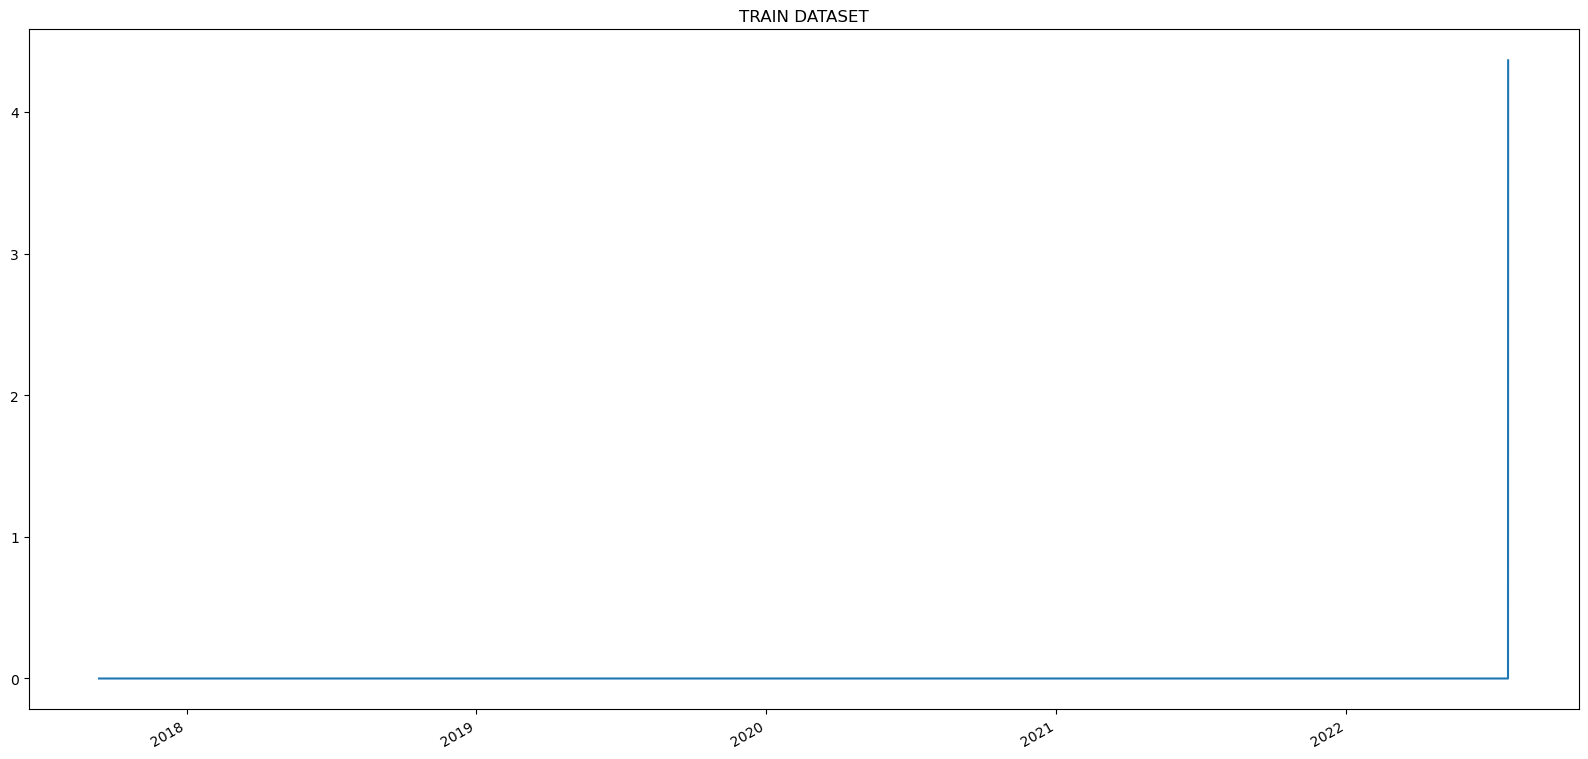

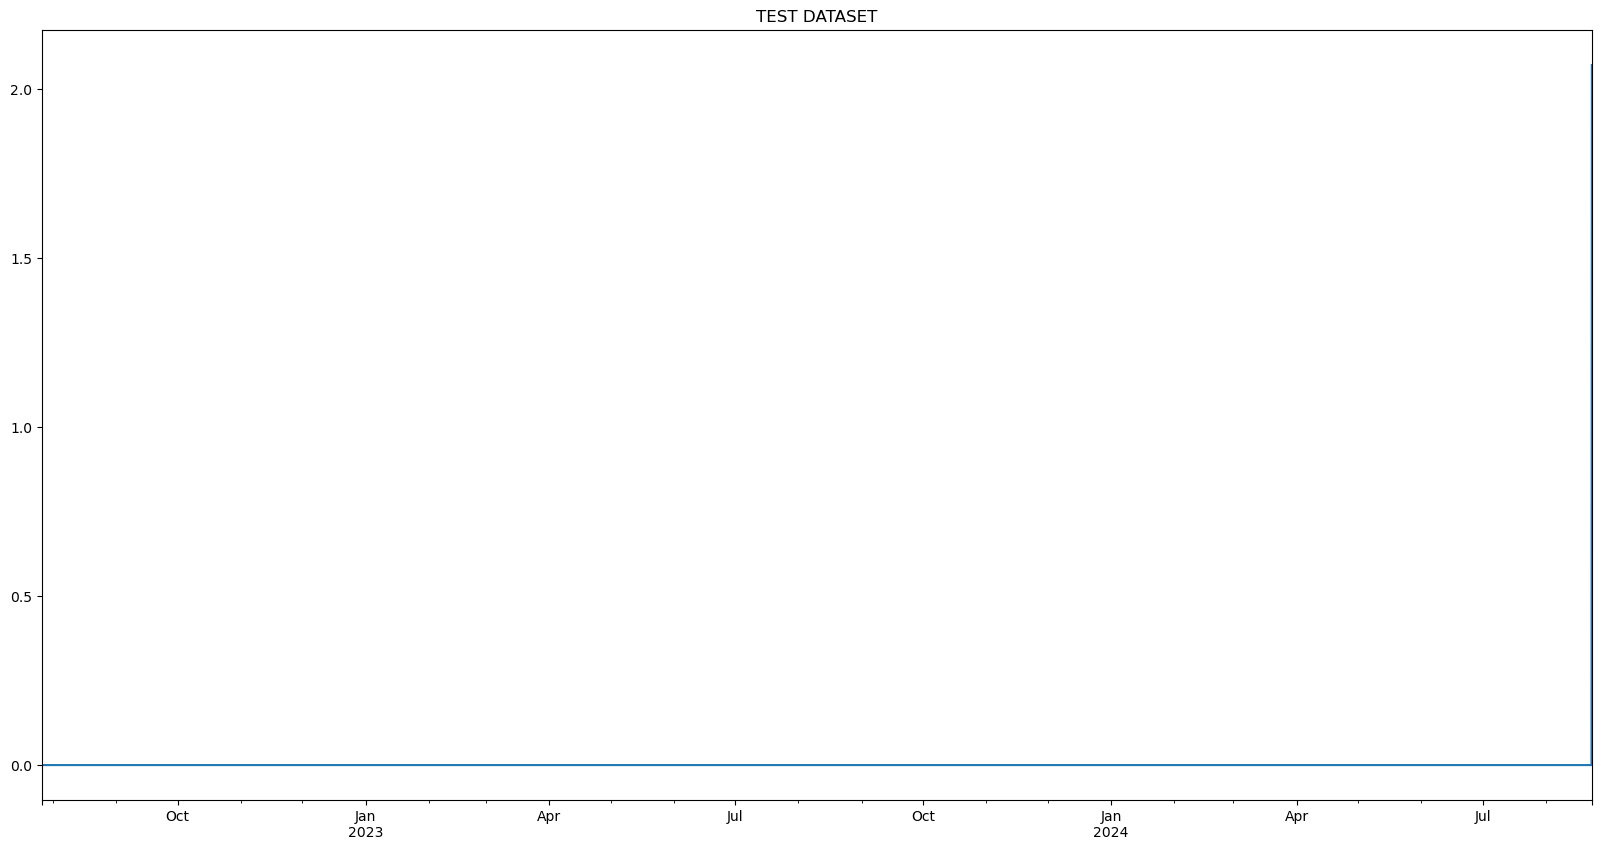

In [499]:

lookback_window_size = 24; nhours = 4
exchange, asset, quote, timeframe = 'binance', 'BTC', 'USDT', '4h'
df = load_candles(exchange,asset, quote, timeframe)#[:'2022']#.iloc[-35000:-5000]
# df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
params = {'conversion_periods':30, 'base_periods':60, 'lagging_span2_periods':120, 'displacement':30}
df_indicators = ichimoku_cloud_indicator(df, **params
    ).join(df[['high','low','close','open']]
    ).join(create_moving_average_features(df, ema_periods=[5,9,14,21,50,120], sma_periods=[5,9,14,21,50,120])
    ).dropna()
compare_columns = [('tenkan', 'kijun', 'close'), ('kumo_upper','close'), ('lead_span_A', 'lead_span_B', 'close')
    ,('ema_14','ema_21'), ('ema_21', 'ema_50'), ('ema_50','ema_120'),('ema_5', 'ema_9'),('ema_9', 'ema_14')
    ,('ema_14', 'sma_14'),('ema_21', 'sma_21'),('ema_50', 'sma_50')
    ,('sma_21', 'sma_50'),('sma_21', 'sma_14'),('sma_50', 'sma_14'),('sma_5', 'sma_14')
    ,('close', 'ema_9'),('close', 'ema_14'),('close', 'ema_21'),('close', 'ema_50')
]

df_comp_features = create_comparison_features(df_indicators, compare_columns).dropna()
log_prices = df.close.apply(np.log)[df_comp_features.index]

train_size = 0.7

# Perform the train-test split
train_df, test_df, train_log_prices, test_log_prices = train_test_split(df_comp_features, log_prices, train_size)


# Initialize the training and testing environments
train_env = TradingEnv(train_df, train_log_prices, lookback_window_size=10)
test_env = TradingEnv(test_df, test_log_prices, lookback_window_size=10)

# Initialize the SARSA agent with overfitting prevention
agent = SARSATabularAgent(env=train_env, epsilon=0.5, alpha=0.05, gamma=0.99, min_epsilon=0.001, epsilon_decay=0.995, early_stopping_threshold=3)

# Train the agent using SARSA
agent.train(num_episodes=20)

# with open('SARSA-TradingEnv.pkl', 'wb') as f: pickle.dump(env, f)
# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)

train_backtest_df = perform_backtest(agent, train_env)
train_backtest_df.cumulative_pnl.apply(np.expm1).plot(figsize=(20,10),title='TRAIN DATASET');plt.show();
# Test the agent on the test environment
test_backtest_df = perform_backtest(agent, test_env)
test_backtest_df.cumulative_pnl.apply(np.expm1).plot(figsize=(20,10),title='TEST DATASET');plt.show();

# with open('complex_object.pkl', 'rb') as f: env = pickle.load(f)


<Axes: title={'center': 'TEST DATASET'}>

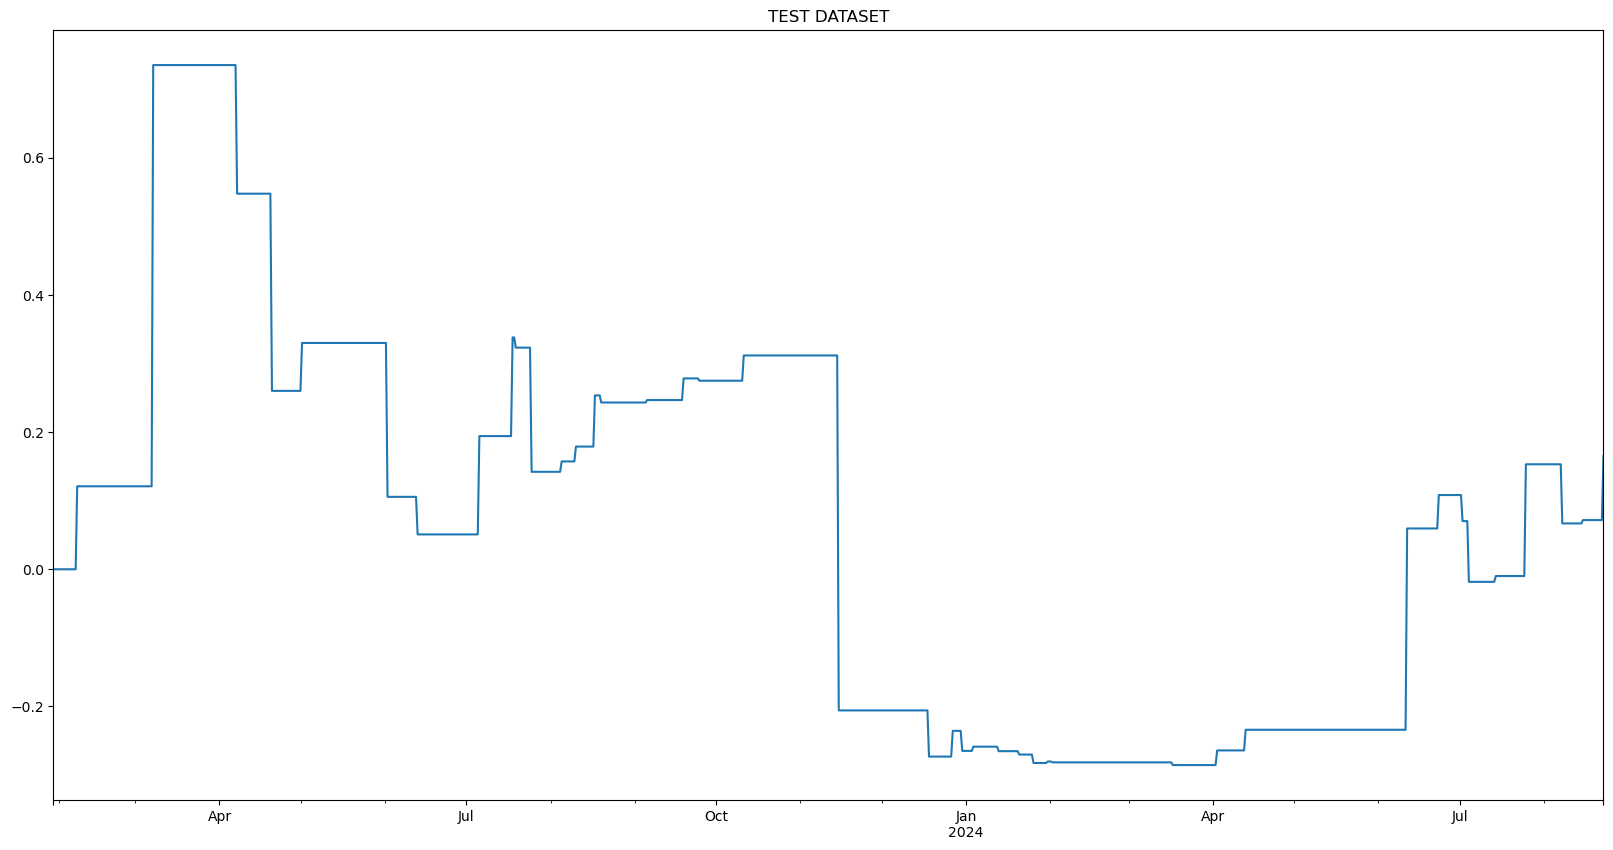

In [465]:

# with open('SARSA-Agent.pkl', 'wb') as f: pickle.dump(agent, f)
# with open('SARSA-Agent.pkl', 'rb') as f: agent = pickle.load(f)

# lookback_window_size = 4
exchange, asset, quote, timeframe = 'binance', 'BTC', 'USDT', '1h'
df = load_candles(exchange,asset, quote, timeframe)['2022-11':]#.iloc[-35000:-5000]
df = df.resample(f'{nhours}H').agg({'open': 'first','high': 'max','low': 'min','close': 'last','volume': 'sum'})
# params = {'conversion_periods':30, 'base_periods':60, 'lagging_span2_periods':120, 'displacement':30}
df_indicators = ichimoku_cloud_indicator(df, **params
    ).join(df[['high','low','close','open']]
    ).join(create_moving_average_features(df, ema_periods=[5,9,14,21,50,120], sma_periods=[5,9,14,21,50,120])
    ).dropna()
df_comp_features = create_comparison_features(df_indicators, compare_columns).dropna()
test_env = TradingEnv(df_comp_features, log_prices, lookback_window_size=lookback_window_size)

df_backtest = perform_backtest(agent, test_env)
df_backtest.cumulative_pnl.apply(np.expm1).plot(figsize=(20,10),title='TEST DATASET')

In [ ]:

# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs,_ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, and cumulative PnL
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(env.cumulative_pnl)
        price_log.append(env.df['close'].iloc[env.current_step])

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': price_log,
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)        
    }, index=env.df.index[lookback_window_size+1:])


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [ ]:

agent.sarsa(num_episodes=10)
with open('SARSA-TradingEnv.pkl', 'wb') as f: pickle.dump(env, f)

In [ ]:
# asset, quote, timeframe, exchange = 'BTC', 'USDT', '8h', 'binance'
# data = get_fib_data(asset, quote, timeframe, exchange)

asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
df = load_candles(exchange,asset, quote, timeframe)['2023':]#.iloc[-35000:-5000]
logprice, ldf_ichimoku = load_ichi_df(df, params)
# Wrap the environment
env = DummyVecEnv([lambda: TradingEnv(ldf_ichimoku[features], logprice, lookback_window_size=lookback_window_size)])
# Use VecNormalize to normalize both observations and rewards
env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10., clip_reward=10.)
# env = TradingEnv(ldf_ichimoku,ldf_ichimoku.close, lookback_window_size=lookback_window_size)
# env = make_vec_env( lambda: TradingEnv(data, lookback_window_size=10),n_envs=num_cpu,seed=0,vec_env_cls=DummyVecEnv)
# env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

        # Example usage with vectorized results
results_list = backtest_vec(env, lookback_window_size, model=model)
# plot_results_vec(results_list)
plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=None)
# env.reset().shape
# Backtest the environment with random actions
# results = backtest(env, lookback_window_size, model=model)
# plot_results(results)

In [ ]:

plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=(2000, 1000))
# results.sum()

In [ ]:
(results_list)

In [ ]:

import numpy as np
import pandas as pd

def pad_log(log, target_length):
    """Pad the log with NaN values to reach the target length."""
    padding_length = target_length - len(log)
    if padding_length > 0:
        return log + [np.nan] * padding_length
    return log

def backtest_vec(env, lookback_window_size, model=None, render=False):
    # Reset the environment for all parallel environments
    obs = env.reset()  # Only one value (observation) is returned by VecEnv's reset()
    done = np.array([False] * env.num_envs)
    step = 0

    # Initialize logs for all environments
    actions_log = [[] for _ in range(env.num_envs)]
    positions_log = [[] for _ in range(env.num_envs)]
    pnl_log = [[] for _ in range(env.num_envs)]
    price_log = [[] for _ in range(env.num_envs)]

    while not np.all(done):  # Continue until all environments are done
        # Get action from the model if provided, otherwise random action for testing
        if model:
            actions, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            actions = np.random.choice([0, 1, 2, 3], size=env.num_envs)  # Random actions for testing

        # Take a step in all environments (VecEnv step returns 4 values)
        obs, rewards, dones, infos = env.step(actions)

        # 'dones' already includes both termination and truncation statuses
        done = dones

        # Log the action, position, cumulative PnL, and price for each environment
        for i in range(env.num_envs):
            actions_log[i].append(actions[i])
            positions_log[i].append(infos[i].get('position', None))  # Log position
            pnl_log[i].append(infos[i].get('cumulative_pnl', 0))  # Log cumulative PnL
            price_log[i].append(infos[i].get('price', 0))  # Log current price

        # Optionally render the environment (this will render only the first environment for simplicity)
        if render and step % 100 == 0:
            env.render()

        step += 1

    # Determine the maximum log length
    max_log_length = max(len(log) for log in price_log)

    # Pad logs to ensure they all have the same length
    for i in range(env.num_envs):
        actions_log[i] = pad_log(actions_log[i], max_log_length)
        positions_log[i] = pad_log(positions_log[i], max_log_length)
        pnl_log[i] = pad_log(pnl_log[i], max_log_length)
        price_log[i] = pad_log(price_log[i], max_log_length)

    # Convert logs to pandas DataFrames for each environment
    results_list = []
    for i in range(env.num_envs):
        index = env.get_attr('df')[i].index[lookback_window_size+1:lookback_window_size+1+max_log_length]
        results_list.append(pd.DataFrame({
            'Price': price_log[i],
            'Action': actions_log[i],
            'Position': positions_log[i],
            'PnL': np.expm1(pnl_log[i])  # Transform PnL back from log if necessary
        }, index=index))  # Adjust index to match log length

    return results_list

def plot_results_vec_with_custom_ichimoku(results_list, df_ichimoku, window=None):
    """Plot results for each environment alongside the original DataFrame with custom Ichimoku columns."""
    
    for env_index, results in enumerate(results_list):
        # Ensure the indices are aligned between the results and the original df_ichimoku
        aligned_df = df_ichimoku.loc[results.index]  # Align based on the results' index
        
        # If window is specified, apply the (start, len) window
        if window:
            start, length = window
            
            # Perform validation checks
            if start < 0 or start >= len(aligned_df):
                print(f"Warning: Start index {start} out of bounds. Using 0 as start.")
                start = 0  # Reset to start if out of bounds
            
            end = start + length
            if end > len(aligned_df):
                print(f"Warning: End index {end} out of bounds. Adjusting to fit available data.")
                end = len(aligned_df)  # Adjust end to fit the data length
            
            # Apply the slicing window
            aligned_df = aligned_df.iloc[start:end]
            results = results.iloc[start:end]

        fig, ax1 = plt.subplots(figsize=(20, 6))

        # Plot original close price from df_ichimoku on the primary y-axis
        ax1.plot(aligned_df.index, aligned_df['close'], label='Close Price', color='blue')

        # Plot Ichimoku Cloud indicators from df_ichimoku with your custom column names
        ax1.plot(aligned_df.index, aligned_df['tenkan'], label='Tenkan (Conversion Line)', linestyle='--', color='orange')
        ax1.plot(aligned_df.index, aligned_df['kijun'], label='Kijun (Base Line)', linestyle='--', color='red')
        ax1.plot(aligned_df.index, aligned_df['kumo_upper'], label='Kumo Upper', linestyle='--', color='green')
        ax1.plot(aligned_df.index, aligned_df['kumo_lower'], label='Kumo Lower', linestyle='--', color='purple')

        ax1.set_xlabel('Step')
        ax1.set_ylabel('Price & Ichimoku Indicators')

        # Mark buy (open long), sell (open short), and close actions using vertical lines
        buy_signals = results[results['Action'] == 1]
        sell_signals = results[results['Action'] == 2]
        close_signals = results[results['Action'] == 3]

        # Plot vertical lines for buys
        for idx in buy_signals.index:
            ax1.axvline(x=idx, color='green', linestyle='--', label='Buy (Long)', lw=1)

        # Plot vertical lines for sells
        for idx in sell_signals.index:
            ax1.axvline(x=idx, color='red', linestyle='--', label='Sell (Short)', lw=1)

        # Plot vertical lines for closes
        # for idx in close_signals.index:
        #     ax1.axvline(x=idx, color='orange', linestyle='--', label='Close', lw=1)

        # Plot cumulative PnL on the secondary y-axis
        ax2 = ax1.twinx()
        ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.7)
        ax2.set_ylabel('Cumulative PnL')

        # Add legends and titles (to avoid duplicate labels in legends)
        handles, labels = ax1.get_legend_handles_labels()
        unique_labels = dict(zip(labels, handles))
        fig.legend(unique_labels.values(), unique_labels.keys(), loc='upper left')

        plt.title(f'Backtest Results with Custom Ichimoku for Environment {env_index + 1}')

        # Show plot
        plt.show()

        # Optionally print results (you can remove this if you only want plots)
        print(f"Results for Environment {env_index + 1}:")
        print(results)




In [ ]:

# Backtesting function
def backtest(env, lookback_window_size, model=None, render=False):
    # Initialize variables for tracking
    obs,_ = env.reset()
    done = False
    step = 0

    actions_log = []
    positions_log = []
    pnl_log = []
    price_log = []

    while not done:
        # Get action from the model if provided, otherwise random action for testing
        if model:
            action, _ = model.predict(obs, deterministic=True)  # Use a trained model if available
        else:
            action = np.random.choice([0, 1, 2, 3])  # Random actions for testing

        # Take a step in the environment
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Log the action, position, and cumulative PnL
        actions_log.append(action)
        positions_log.append(env.position)
        pnl_log.append(env.cumulative_pnl)
        price_log.append(env.df['close'].iloc[env.current_step])

        # Optionally render the environment
        if render:
            env.render()

        step += 1

    # Return logs for further analysis or visualization
    return pd.DataFrame({
        'Price': price_log,
        'Action': actions_log,
        'Position': positions_log,
        'PnL': np.expm1(pnl_log)        
    }, index=env.df.index[lookback_window_size+1:])


def plot_results(results):    
    # Analyze and visualize the results
    # Plot the results
    fig, ax1 = plt.subplots(figsize=(20, 6))

    # Plot price on primary y-axis
    ax1.plot(results.index, results['Price'], label='Price', color='blue')
    ax1.set_xlabel('Step')
    ax1.set_ylabel('Price')

    # Mark buy (open long) and sell (open short) actions
    buy_signals = results[results['Action'] == 1]
    sell_signals = results[results['Action'] == 2]
    close_signals = results[results['Action'] == 3]

    ax1.scatter(buy_signals.index, buy_signals['Price'], color='green', marker='^', label='Buy (Long)', lw=1)
    ax1.scatter(sell_signals.index, sell_signals['Price'], color='red', marker='v', label='Sell (Short)', lw=1)
    ax1.scatter(close_signals.index, close_signals['Price'], color='orange', marker='x', label='Close', lw=1)

    # Plot cumulative PnL on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(results.index, results['PnL'], label='Cumulative PnL', color='teal', linestyle='-', lw=5, alpha=0.3)
    ax2.set_ylabel('Cumulative PnL')

    fig.legend(loc='upper left')
    plt.title('Backtest Results: Price and Cumulative PnL')
    plt.show()

    print(results)


In [ ]:
# asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
# data = get_fib_data(asset, quote, timeframe, exchange)

asset, quote, timeframe, exchange = 'ADA', 'USDT', '8h', 'binance'
data = load_bb(asset, quote, timeframe, exchange, periods=[7,14,21,50,120], multiplier=2).dropna()
# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('ADA', 'USDT', '8h', 'binance', params)
# Initialize the environment
lookback_window_size=3
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:


# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# data = get_ichi_data('BTC', 'USDT', '12h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '8h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)

# Initialize the environment
lookback_window_size=10
env = TradingEnv(data, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:

# params = {'tenkan_period': 140, 'kijun_period': 376, 'senkou_span_b_period': 420, 'chikou_span_delay': 180}
# df = get_data('SOL', 'USDT', '4h', 'binance', params)

asset, quote, timeframe, exchange = 'DOT', 'USDT', '4h', 'binance'
data = get_fib_data(asset, quote, timeframe, exchange)
# Initialize the environment
lookback_window_size=10
env = TradingEnv(df, lookback_window_size=lookback_window_size)

# Backtest the environment with random actions
results = backtest(env, lookback_window_size=lookback_window_size, model=model)
plot_results(results)


In [ ]:
import matplotlib.pyplot as plt

# Plot the price, cumulative log-return PnL, and buy/sell signals
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the closing price on the primary y-axis
ax1.plot(env.df.index, env.df['close'], label='Close Price', color='blue', lw=2)

# Plot entry (buy) and exit (sell) signals as vertical lines
for idx, row in tracking_df.iterrows():
    if row['action'] == 2:  # Buy signal
        ax1.axvline(x=idx, color='green', linestyle='--', lw=1, label='Buy')
    elif row['action'] == 0:  # Sell signal
        ax1.axvline(x=idx, color='red', linestyle='--', lw=1, label='Sell')

# Create a secondary y-axis for cumulative log-return PnL
ax2 = ax1.twinx()
ax2.plot(tracking_df.index, tracking_df['cumulative_pnl'], label='Cumulative PnL (Log Returns)', color='black', lw=1.5, linestyle='--')
ax2.set_ylabel('Cumulative PnL (Log Returns)')

# Set labels and title
ax1.set_xlabel('Time')
ax1.set_ylabel('Price')
ax1.set_title('Agent Trading Performance: Price, Entry/Exit, and Cumulative PnL (Log Returns)')

plt.show()
